In [1]:
# importa livrarias necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_cleaned.csv")

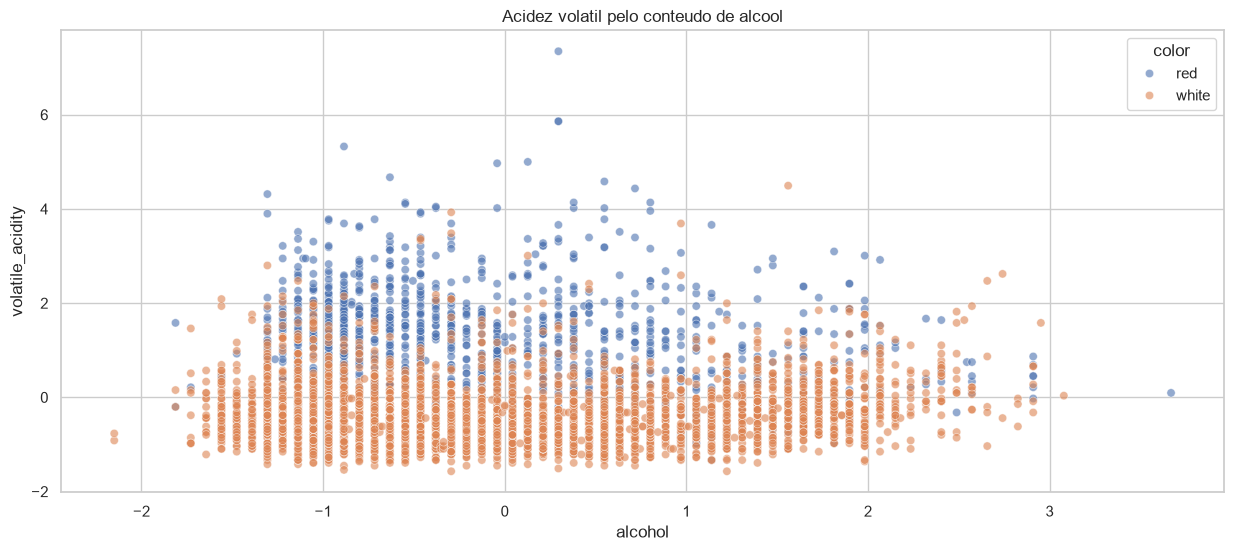

In [3]:
# Grafico conteudo de alcool vs acidez (pesquisa na web diz que estas variaveis sao bastante relacionadas)
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df,
    x='alcohol',
    y='volatile_acidity',
    hue='color',
    alpha=0.6
)
plt.title('Acidez volatil pelo conteudo de alcool')
plt
plt.show()

In [4]:
# Definindo os features e mostrando o cabecario e 5 linhas
features = ['fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol']
X = df[features].copy()
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152


In [5]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.14006434,  2.11534878, -2.16451528, -0.69969941,  0.52388033,
        -1.06927243, -1.41114309,  1.10099559,  1.77930357,  0.1779407 ,
        -0.96915199],
       [ 0.44319875,  3.18529696, -2.16451528, -0.54413546,  1.12073572,
        -0.28290452, -0.82983876,  0.76375321, -0.15379707,  0.97938943,
        -0.63183308],
       [ 0.44319875,  2.47199817, -1.89267181, -0.61080573,  0.95795697,
        -0.84459589, -1.05883743,  0.83120168,  0.22035144,  0.77902725,
        -0.63183308],
       [ 3.01984128, -0.38119697,  1.64129325, -0.69969941,  0.49675054,
        -0.73225761, -0.95314573,  1.16844407, -0.40322942,  0.31151549,
        -0.63183308],
       [ 0.14006434,  1.87758252, -2.16451528, -0.72192284,  0.49675054,
        -0.95693416, -1.30545139,  1.10099559,  1.77930357,  0.1779407 ,
        -0.96915199]])

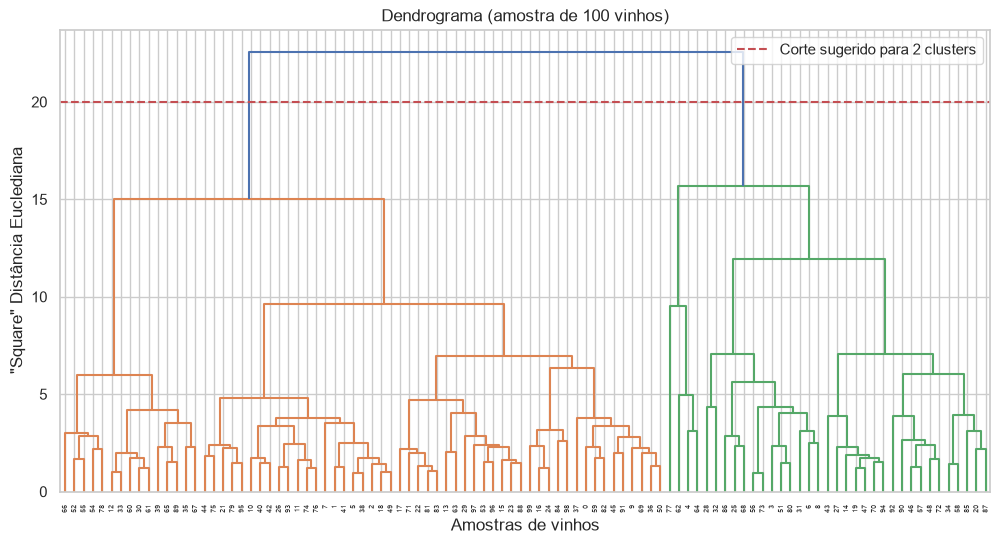

In [6]:
# Produz dendograma com uma amostra dos dados
amostra_indices = np.random.choice(len(X), size=100, replace=False)
X_amostra = X_scaled[amostra_indices]

# Calcular linkage para o dendrograma
Z = linkage(X_amostra, method='ward')

# Plotar dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma (amostra de 100 vinhos)')
plt.xlabel('Amostras de vinhos')
plt.ylabel('"Square" Distância Euclediana')
plt.axhline(y=20, color='r', linestyle='--', label='Corte sugerido para 2 clusters')
plt.legend()
plt.show()

In [7]:
# Execucao do modelo HAC
n_clusters_escolhido = 2

linkage_method = 'ward'
hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters = hac.fit_predict(X_scaled)
clusters[:20]

hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters_treino = hac.fit_predict(X_scaled)
clusters_treino[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
#Adicionando os clusters ao DataFrame principal
df['cluster'] = clusters_treino
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,cluster
0,0.140064,2.115349,-2.164515,-0.699699,0.523880,-1.069272,-1.411143,1.100996,1.779304,0.177941,-0.969152,5,red,1
1,0.443199,3.185297,-2.164515,-0.544135,1.120736,-0.282905,-0.829839,0.763753,-0.153797,0.979389,-0.631833,5,red,1
2,0.443199,2.471998,-1.892672,-0.610806,0.957957,-0.844596,-1.058837,0.831202,0.220351,0.779027,-0.631833,5,red,1
3,3.019841,-0.381197,1.641293,-0.699699,0.496751,-0.732258,-0.953146,1.168444,-0.403229,0.311515,-0.631833,6,red,1
4,0.140064,1.877583,-2.164515,-0.721923,0.496751,-0.956934,-1.305451,1.100996,1.779304,0.177941,-0.969152,5,red,1


In [9]:
# Quantos vinhos em cada cluster
df['cluster'].value_counts().sort_index()

cluster
0    3842
1    1478
Name: count, dtype: int64

In [10]:
# Resumo dos clusters
clusters_validos = sorted(df['cluster'].unique())
n_clusters_encontrados = len(clusters_validos)
n_pontos_total = len(df)

print('Número de clusters encontrados:', n_clusters_encontrados)
print('Total de pontos:', n_pontos_total)

Número de clusters encontrados: 2
Total de pontos: 5320


In [11]:
# Avaliação rápida com silhouette score

mask_todos = df['cluster'] >= 0
X_todos = X_scaled[mask_todos]
labels_todos = df.loc[mask_todos, 'cluster']

if len(set(labels_todos)) >= 2:
    sil = silhouette_score(X_todos, labels_todos)
    print('Silhouette Score:', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: menos de 2 clusters válidos.')

Silhouette Score: 0.2607


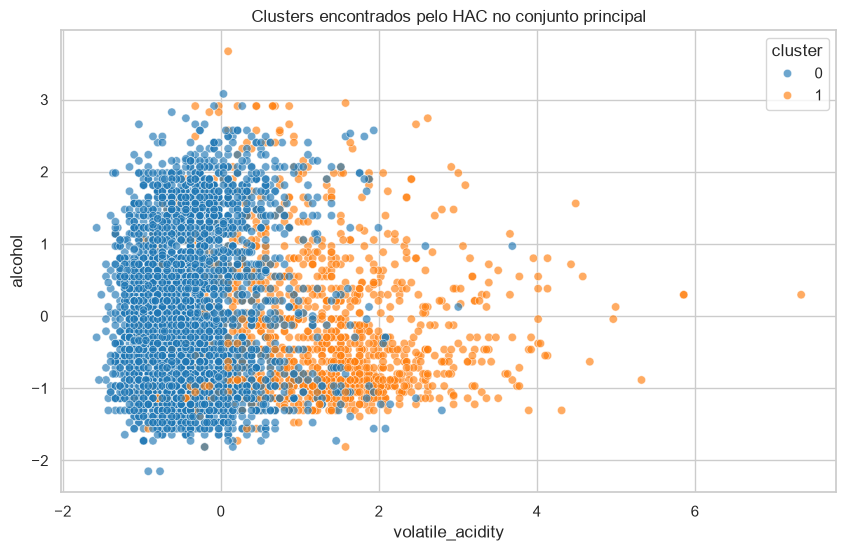

In [12]:
# Visualização dos clusters encontrados no conjunto principal

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='volatile_acidity',
    y='alcohol',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)
plt.title('Clusters encontrados pelo HAC no conjunto principal')
plt.show()

Calculando Silhouette Scores para todas as variações de linkage...
Linkage 'ward': Melhor Score foi 0.2607 com k = 2
Linkage 'complete': Melhor Score foi 0.7897 com k = 2
Linkage 'average': Melhor Score foi 0.7897 com k = 2
Linkage 'single': Melhor Score foi 0.7897 com k = 2


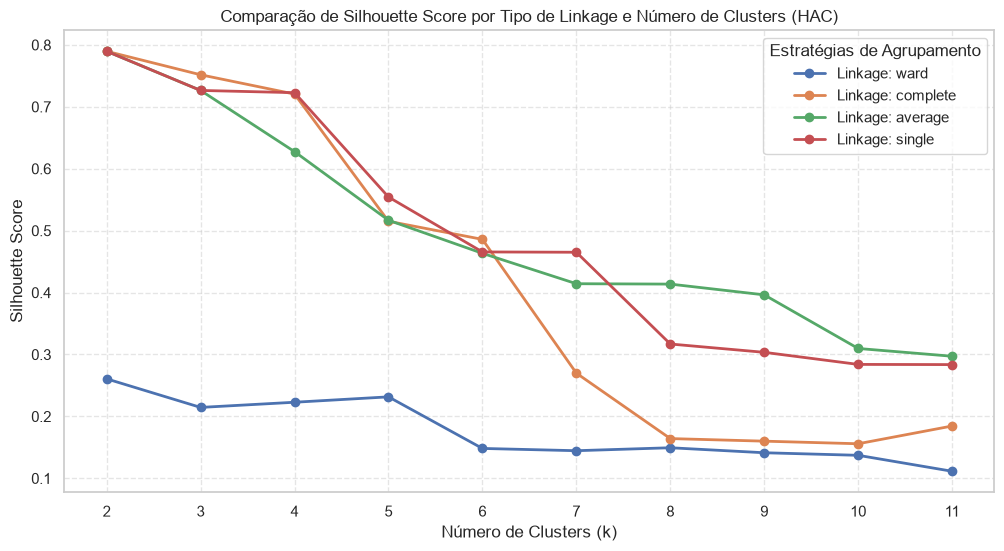

In [13]:
# Definindo as 4 variações de linkage suportadas pelo HAC
variacoes_linkage = ['ward', 'complete', 'average', 'single']

# Definindo o intervalo para 10 diferentes valores de k (de 2 a 11)
valores_k = range(2, 12)

# Criando a figura do gráfico para plotar todas as linhas juntas
plt.figure(figsize=(12, 6))

print("Calculando Silhouette Scores para todas as variações de linkage...")

# Loop principal: passa por cada tipo de linkage
for metodo_linkage in variacoes_linkage:
    scores_do_metodo = []
    
    # Loop secundário: passa por cada número de clusters (k)
    for k in valores_k:
        # Configura e treina o modelo HAC com o linkage e k atuais
        hac_teste = AgglomerativeClustering(n_clusters=k, linkage=metodo_linkage)
        labels_teste = hac_teste.fit_predict(X_scaled)
        
        # Calcula o silhouette score para esta combinação
        score = silhouette_score(X_scaled, labels_teste)
        scores_do_metodo.append(score)
        
    # Exibe no terminal o melhor resultado encontrado para este método específico
    maior_score = max(scores_do_metodo)
    k_ideal = valores_k[scores_do_metodo.index(maior_score)]
    print(f"Linkage '{metodo_linkage}': Melhor Score foi {maior_score:.4f} com k = {k_ideal}")
    
    # Plota a linha deste método de linkage no gráfico geral
    plt.plot(valores_k, scores_do_metodo, marker='o', linestyle='-', label=f'Linkage: {metodo_linkage}', linewidth=2)

# Customização e finalização do gráfico comparativo
plt.title('Comparação de Silhouette Score por Tipo de Linkage e Número de Clusters (HAC)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estratégias de Agrupamento')
plt.show()